PROJECT-TOMATO PRICE FORECASTING BY USING (LR,RF,DT)

# LINEAR REGRESSION

In [ ]:
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [ ]:
# 2. LOAD DATASET
# ===============================
df = pd.read_csv('tomato_price_dataset.csv')

print("First 5 rows:")
print(df.head())


First 5 rows:
         Date  Arrivals  Temperature    Rainfall  Month       Price
0  2018-01-01       152    34.369145   32.169635      1  439.124193
1  2018-01-02       485    30.700735  111.608465      1  256.585196
2  2018-01-03       398    29.532390  162.350443      1  201.317196
3  2018-01-04       320    36.771651  148.342412      1  290.111706
4  2018-01-05       156    24.101551  176.290156      1  270.076613


In [ ]:
# 3. PREPROCESSING
# ===============================

# Convert Date column to numeric features
df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

# Drop original Date column
df.drop(columns=['Date'], inplace=True)

# Remove missing values
df.dropna(inplace=True)


In [ ]:
# 4. FEATURES & TARGET
# ===============================
X = df.drop(columns=['Price'])   # Features
y = df['Price']                  # Target

In [ ]:
# 5. TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# 6. TRAIN MODEL
# ===============================
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# 7. PREDICTION
# ===============================
y_pred = model.predict(X_test)

In [ ]:
# 8. EVALUATION
# ===============================
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nLinear Regression Results:")
print("R2 Score:", r2)
print("RMSE:", rmse)



Linear Regression Results:
R2 Score: 0.7833608627853776
RMSE: 43.706398866367905


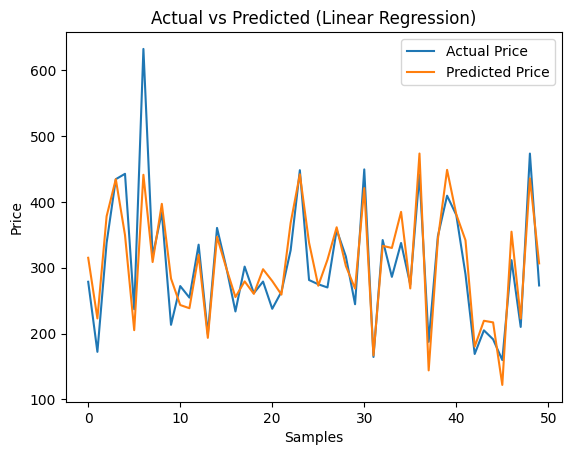

In [ ]:

# 9.Plot Actual values
plt.plot(y_test.values[:50], label='Actual Price')

# Plot Predicted values
plt.plot(y_pred[:50], label='Predicted Price')

# Labels & Title
plt.xlabel("Samples")
plt.ylabel("Price")
plt.title("Actual vs Predicted (Linear Regression)")

# Legend to show colors
plt.legend()

plt.show()

In [ ]:
# 10. SAMPLE OUTPUT
# ===============================
print("\nSample Predictions:")
print(pd.DataFrame({
    'Actual': y_test.values[:5],
    'Predicted': y_pred[:5]
}))


Sample Predictions:
       Actual   Predicted
0  278.659155  315.107298
1  172.165455  222.899942
2  337.553938  378.138769
3  434.555156  434.569295
4  442.705213  349.600882


In [ ]:
# Example: Predict future price
# The model was trained on features: 'Arrivals', 'Temperature', 'Rainfall', 'Month', 'year', 'month', 'day'.
# The future_data must match these column names and order.
# Using placeholder/mean values for 'Temperature' and 'Rainfall' for demonstration, as they were not provided.
# 'Month' needs to be capitalized to match the training data feature.
future_data = pd.DataFrame({
    'Arrivals': [300], # Renamed from 'arrivals_quintal' to 'Arrivals'
    'Temperature': [29.839841], # Using mean of X_train['Temperature']
    'Rainfall': [99.789189],    # Using mean of X_train['Rainfall']
    'Month': [7],         # Ensuring 'Month' is capitalized and matches the provided month value
    'year': [2026],
    'month': [7],
    'day': [15]
})

future_price = model.predict(future_data)
print("\nPredicted Future Price:", future_price[0])


Predicted Future Price: 334.4364322850479


# RANDOM FOREST MODEL

In [ ]:
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt

In [ ]:
# 2. LOAD DATASET
# ===============================
df = pd.read_csv('tomato_price_dataset.csv')

print("Dataset Preview:")
print(df.head())

Dataset Preview:
         Date  Arrivals  Temperature    Rainfall  Month       Price
0  2018-01-01       152    34.369145   32.169635      1  439.124193
1  2018-01-02       485    30.700735  111.608465      1  256.585196
2  2018-01-03       398    29.532390  162.350443      1  201.317196
3  2018-01-04       320    36.771651  148.342412      1  290.111706
4  2018-01-05       156    24.101551  176.290156      1  270.076613


In [ ]:
# 3. PREPROCESSING
# ===============================

# Convert Date to features
df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

# Drop original Date
df.drop(columns=['Date'], inplace=True)

# Remove missing values
df.dropna(inplace=True)

In [ ]:
# 4. FEATURES & TARGET
# ===============================
X = df.drop(columns=['Price'])
y = df['Price']



In [ ]:
# 5. TRAIN TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# 6. RANDOM FOREST MODEL
# ===============================
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf.fit(X_train, y_train)



RandomForestRegressor(max_depth=12, n_estimators=300, random_state=42)

In [ ]:
# 7. PREDICTION
# ===============================
y_pred = rf.predict(X_test)

In [ ]:
# 8. EVALUATION
# ===============================
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nRandom Forest Results:")
print("R2 Score:", r2)
print("RMSE:", rmse)



Random Forest Results:
R2 Score: 0.9653480158428291
RMSE: 17.479967454854908


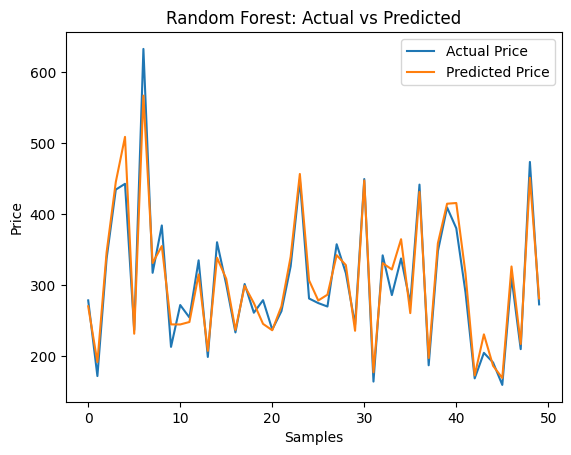

In [ ]:
# 9. GRAPH (ACTUAL vs PREDICTED)
# ===============================
plt.figure()

plt.plot(y_test.values[:50], label='Actual Price')
plt.plot(y_pred[:50], label='Predicted Price')

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Samples")
plt.ylabel("Price")

plt.legend()
plt.show()

In [ ]:
# 10. SAMPLE OUTPUT
# ===============================
print("\nSample Predictions:")
print(pd.DataFrame({
    'Actual': y_test.values[:5],
    'Predicted': y_pred[:5]
}))


Sample Predictions:
       Actual   Predicted
0  278.659155  270.330832
1  172.165455  191.789302
2  337.553938  346.227960
3  434.555156  445.288149
4  442.705213  508.750971


In [ ]:
# Example: Predict future price
# The model was trained on features: 'Arrivals', 'Temperature', 'Rainfall', 'Month', 'year', 'month', 'day'.
# The future_data must match these column names and order.
# Using placeholder/mean values for 'Temperature' and 'Rainfall' for demonstration, as they were not provided.
# 'Month' needs to be capitalized to match the training data feature.
future_data = pd.DataFrame({
    'Arrivals': [300], # Renamed from 'arrivals_quintal' to 'Arrivals'
    'Temperature': [29.839841], # Using mean of X_train['Temperature']
    'Rainfall': [99.789189],    # Using mean of X_train['Rainfall']
    'Month': [7],         # Ensuring 'Month' is capitalized and matches the provided month value
    'year': [2026],
    'month': [7],
    'day': [15]
})
future_price = model.predict(future_data)
print("\nPredicted Future Price:", future_price[0])



Predicted Future Price: 334.4364322850479


# DECISION TREE  MODEL

In [ ]:
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn import tree

import matplotlib.pyplot as plt

In [ ]:
# 2. LOAD DATASET
# ===============================
df = pd.read_csv('tomato_price_dataset.csv')

print("Dataset Preview:")
print(df.head())

Dataset Preview:
         Date  Arrivals  Temperature    Rainfall  Month       Price
0  2018-01-01       152    34.369145   32.169635      1  439.124193
1  2018-01-02       485    30.700735  111.608465      1  256.585196
2  2018-01-03       398    29.532390  162.350443      1  201.317196
3  2018-01-04       320    36.771651  148.342412      1  290.111706
4  2018-01-05       156    24.101551  176.290156      1  270.076613


In [ ]:
# 3. PREPROCESSING
# ===============================

# Convert Date to features
df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

# Drop original Date
df.drop(columns=['Date'], inplace=True)

# Remove missing values
df.dropna(inplace=True)

In [ ]:
# 4. FEATURES & TARGET
# ===============================
X = df.drop(columns=['Price'])
y = df['Price']

In [ ]:
# 5. TRAIN TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# 6. DECISION TREE MODEL
# ===============================
dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

dt.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42)

In [ ]:
# 7. PREDICTION
# ===============================
y_pred = dt.predict(X_test)

In [ ]:
# 8. EVALUATION
# ===============================
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nDecision Tree Results:")
print("R2 Score:", r2)
print("RMSE:", rmse)



Decision Tree Results:
R2 Score: 0.9252635969535077
RMSE: 25.670992637485746


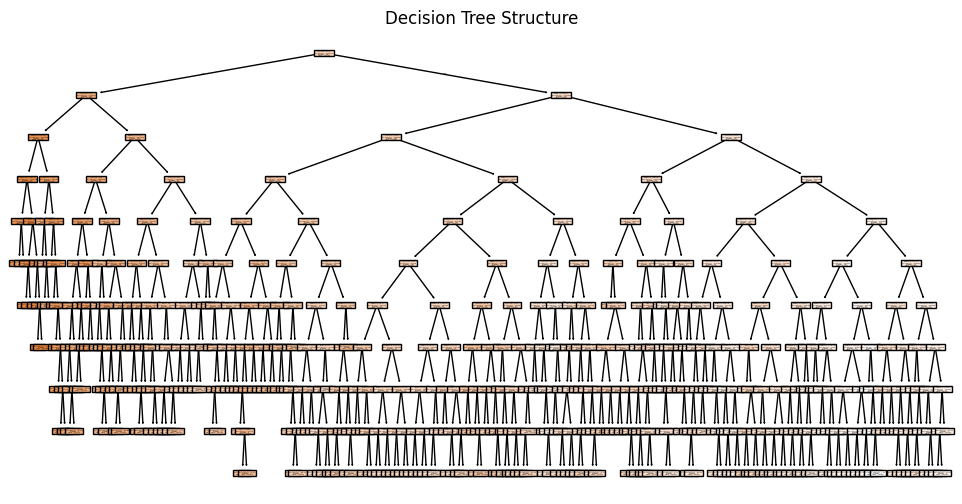

In [ ]:
# 9.1 TREE VISUALIZATION 📊
# =========================================

plt.figure(figsize=(12,6))
tree.plot_tree(dt, feature_names=X.columns, filled=True)
plt.title("Decision Tree Structure")
plt.show()

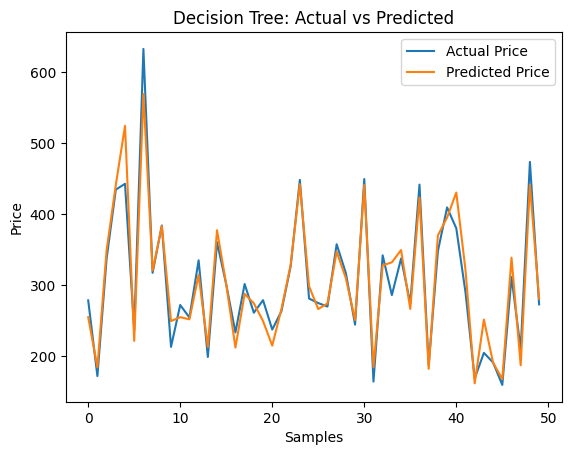

In [ ]:
# 9.2 GRAPH (ACTUAL vs PREDICTED)
# ===============================
plt.figure()

plt.plot(y_test.values[:50], label='Actual Price')
plt.plot(y_pred[:50], label='Predicted Price')

plt.title("Decision Tree: Actual vs Predicted")
plt.xlabel("Samples")
plt.ylabel("Price")

plt.legend()
plt.show()

In [ ]:
# 10. SAMPLE OUTPUT
# ===============================
print("\nSample Predictions:")
print(pd.DataFrame({
    'Actual': y_test.values[:5],
    'Predicted': y_pred[:5]
}))


Sample Predictions:
       Actual   Predicted
0  278.659155  255.053155
1  172.165455  184.450370
2  337.553938  349.081231
3  434.555156  441.040719
4  442.705213  524.351522


In [ ]:
# Example: Predict future price
# The model was trained on features: 'Arrivals', 'Temperature', 'Rainfall', 'Month', 'year', 'month', 'day'.
# The future_data must match these column names and order.
# Using placeholder/mean values for 'Temperature' and 'Rainfall' for demonstration, as they were not provided.
# 'Month' needs to be capitalized to match the training data feature.
future_data = pd.DataFrame({
    'Arrivals': [300], # Renamed from 'arrivals_quintal' to 'Arrivals'
    'Temperature': [29.839841], # Using mean of X_train['Temperature']
    'Rainfall': [99.789189],    # Using mean of X_train['Rainfall']
    'Month': [7],         # Ensuring 'Month' is capitalized and matches the provided month value
    'year': [2026],
    'month': [7],
    'day': [15]
})
future_price = model.predict(future_data)
print("\nPredicted Future Price:", future_price[0])


Predicted Future Price: 334.4364322850479


#COMPARISION OF ALL 3 MODEL

In [ ]:
#1. Train all models
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, n_estimators=300, random_state=42)

In [ ]:
#2. Make predictions
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [ ]:
#3. Calculate metrics (R² & RMSE)
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, rmse

r2_lr, rmse_lr = evaluate(y_test, y_pred_lr)
r2_dt, rmse_dt = evaluate(y_test, y_pred_dt)
r2_rf, rmse_rf = evaluate(y_test, y_pred_rf)

In [ ]:
# 4.COMPARISON TABLE
import pandas as pd

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [r2_lr, r2_dt, r2_rf],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf]
})

print(results)

               Model  R2 Score       RMSE
0  Linear Regression  0.783361  43.706399
1      Decision Tree  0.925264  25.670993
2      Random Forest  0.965348  17.479967


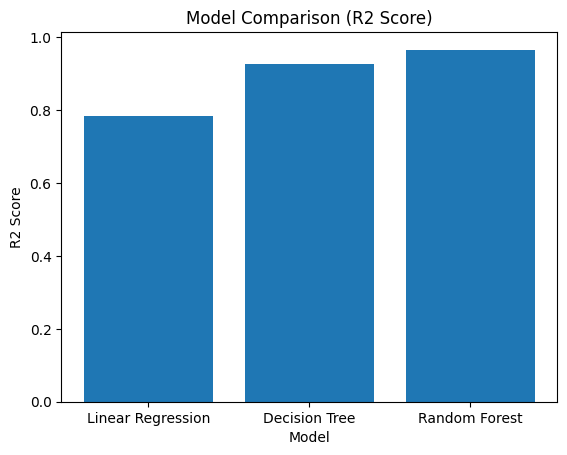

In [ ]:
# 5. BAR GRAPH (MODEL COMPARISON)
# ===============================
plt.figure()
plt.bar(results['Model'], results['R2 Score'])
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.show()


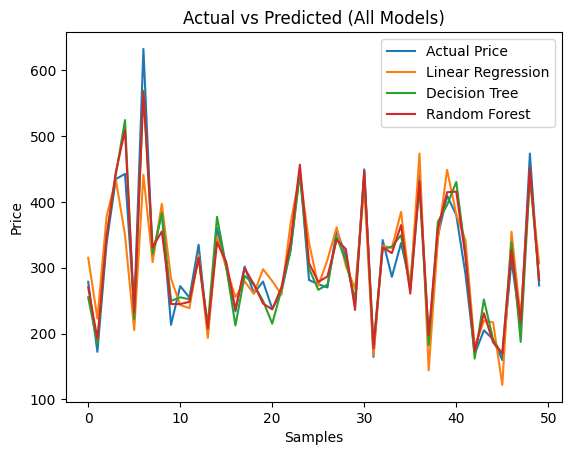

In [ ]:
# 6. ACTUAL vs PREDICTED GRAPH
# ===============================
plt.figure()

plt.plot(y_test.values[:50], label='Actual Price')
plt.plot(y_pred_lr[:50], label='Linear Regression')
plt.plot(y_pred_dt[:50], label='Decision Tree')
plt.plot(y_pred_rf[:50], label='Random Forest')

plt.title("Actual vs Predicted (All Models)")
plt.xlabel("Samples")
plt.ylabel("Price")

plt.legend()
plt.show()

In [ ]:
#7. Best Model Selection
best_model = results.loc[results['R2 Score'].idxmax()]

print("\nBest Model:")
print(best_model)


Best Model:
Model       Random Forest
R2 Score         0.965348
RMSE            17.479967
Name: 2, dtype: object


result=
✔ Use R² Score:
Higher = better ✅
✔ Use RMSE:
Lower = better ✅

In [ ]:
#1.“GridSearchCV finds the best combination of parameters automatically to improve model performance.”

#hypertunning for random regression

In [ ]:
# Hyperparameter Tuning (GridSearchCV)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Model
rf = RandomForestRegressor(random_state=42)

# Grid Search
grid = GridSearchCV(rf, param_grid, cv=3, scoring='r2')
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# Predict
y_pred_best = best_model.predict(X_test)

from sklearn.metrics import r2_score
print("Improved R2 Score:", r2_score(y_test, y_pred_best))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
Improved R2 Score: 0.9656883463662721
